# Notebook 07 - Grad-CAM Explainability: MobileNetV2 (Phase 2)

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 7

---

## Objective

Apply Grad-CAM (Gradient-weighted Class Activation Mapping; Selvaraju et al., 2017) to the fine-tuned model to make its decisions interpretable: for a given image, Grad-CAM highlights the regions whose features most increased the score of the predicted class.

1. Load the fine-tuned model `mobilenet_phase2_best.h5`.
2. For one test image per class, compute the Grad-CAM heatmap.
3. Display the original image alongside its heatmap overlay, labelled with the predicted class and confidence.

## Method note

With `include_top=False` and no pooling, the MobileNetV2 base output is itself the final convolutional feature map (`out_relu`, 7x7x1280). `src.evaluate.build_gradcam_model` exposes this map and re-applies the head in a single functional graph, which avoids the 'graph disconnected' error that occurs when addressing a layer nested inside the base sub-model. The overlay uses a matplotlib colormap (no OpenCV dependency).

## What to look for

Activations concentrated on the fruit (its surface, blemishes, colour transitions) indicate the model is using meaningful evidence. Activations on the background would suggest the model is exploiting spurious cues, which is an important limitation to report honestly.

## 1. Setup and model load

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import tensorflow as tf
from src.utils import SAVED_MODELS
from src.evaluate import generate_gradcam_grid

PROJECT_ROOT = Path.cwd().parent
model = tf.keras.models.load_model(
    str(PROJECT_ROOT / 'saved_models' / SAVED_MODELS['mobilenet_phase2']), compile=False)
print('Loaded:', SAVED_MODELS['mobilenet_phase2'])


Loaded: mobilenet_phase2_best.h5


## 2. Grad-CAM grid (one example per class)

The grid has one row per class in the canonical order, showing the original image and the Grad-CAM overlay. The overlay title marks whether the prediction was correct and reports the predicted class and confidence. Set `n_per_class=3` for a larger appendix-style grid. The figure renders inline and is saved to `results/`.

2026-06-09 15:32:34 [INFO] evaluate: Grad-CAM grid saved to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/gradcam_mobilenet_phase2.png


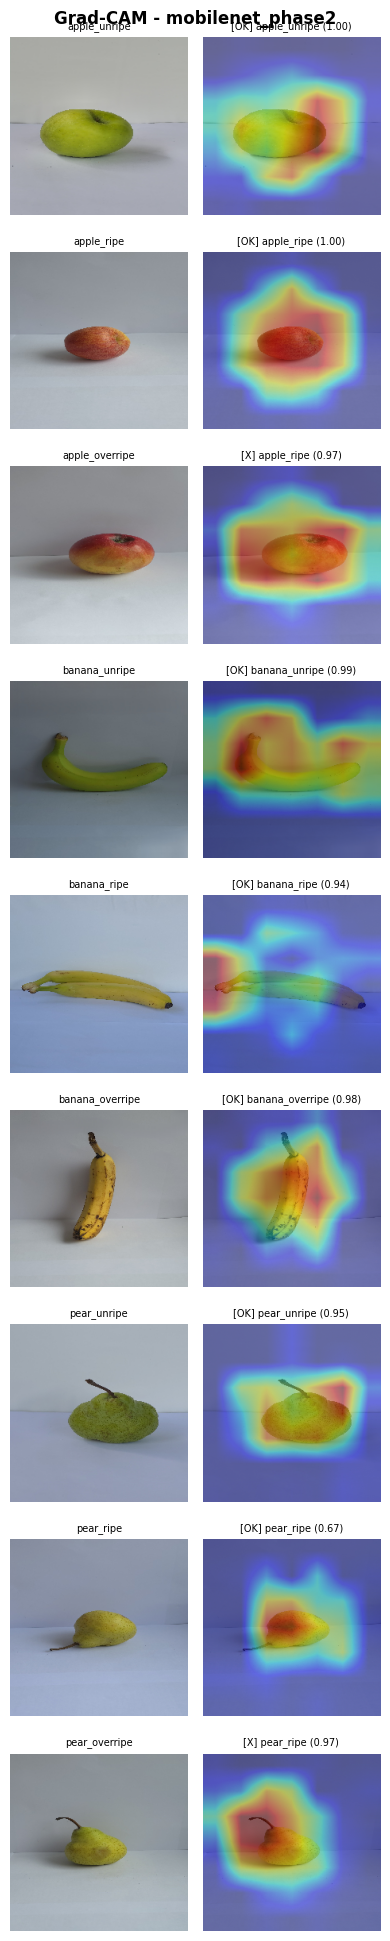

In [2]:
generate_gradcam_grid(
    model,
    splits_dir=str(PROJECT_ROOT / 'dataset_splits'),
    output_dir=str(PROJECT_ROOT / 'results'),
    model_name='mobilenet_phase2',
    n_per_class=1,
    show=True,
)


## 3. Interpretation

Inspect each overlay: for correctly classified examples the warm (red/yellow) region should sit on the fruit, confirming the prediction is driven by the object rather than the background. For any misclassified example, compare the heatmap with the true and predicted classes to understand the error (for instance, attention on a discoloured area may push a *ripe* sample towards *overripe*). Summarise these observations in the report's explainability subsection, and note any cases where attention falls on the background as a limitation.